# Импорты

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from sklearn.datasets import load_boston
import scipy.stats as stats
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
# from IPython.display import Image
%matplotlib inline
sns.set(style="ticks")

# Диагностика данных

In [4]:
# data_original = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")
data_original = pd.read_csv("sample_data/mental_health_digital_behavior_data.csv")
data_original.head()
# data.columns

,daily_screen_time_min,num_app_switches,sleep_hours,notification_count,social_media_time_min,focus_score,mood_score,anxiety_level,digital_wellbeing_score
0,389.8,53,5.9,89,133.2,6.8,8.9,10.0,44.8
1,351.7,52,7.2,79,109.5,5.5,9.4,10.0,43.6
2,398.9,39,8.0,108,84.7,6.7,9.4,9.4,52.6
3,451.4,44,6.5,78,88.9,6.0,9.4,5.1,58.4
4,346.0,43,6.9,35,78.8,8.2,9.4,8.0,59.7


In [5]:
# data = data_original.select_dtypes(exclude=['str'])
data = data_original
data.isna().sum()
data = data.dropna()
data.dtypes


,0
daily_screen_time_min,float64
num_app_switches,int64
sleep_hours,float64
notification_count,int64
social_media_time_min,float64
focus_score,float64
mood_score,float64
anxiety_level,float64
digital_wellbeing_score,float64


In [6]:
def diagnostic_plots(df, variable, title):
    fig, ax = plt.subplots(figsize=(10,7))
    # гистограмма
    plt.subplot(2, 2, 1)
    df[variable].hist(bins=30)
    ## Q-Q plot
    plt.subplot(2, 2, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    # ящик с усами
    plt.subplot(2, 2, 3)
    sns.violinplot(x=df[variable])
    # ящик с усами
    plt.subplot(2, 2, 4)
    sns.boxplot(x=df[variable])
    fig.suptitle(title)
    plt.show()

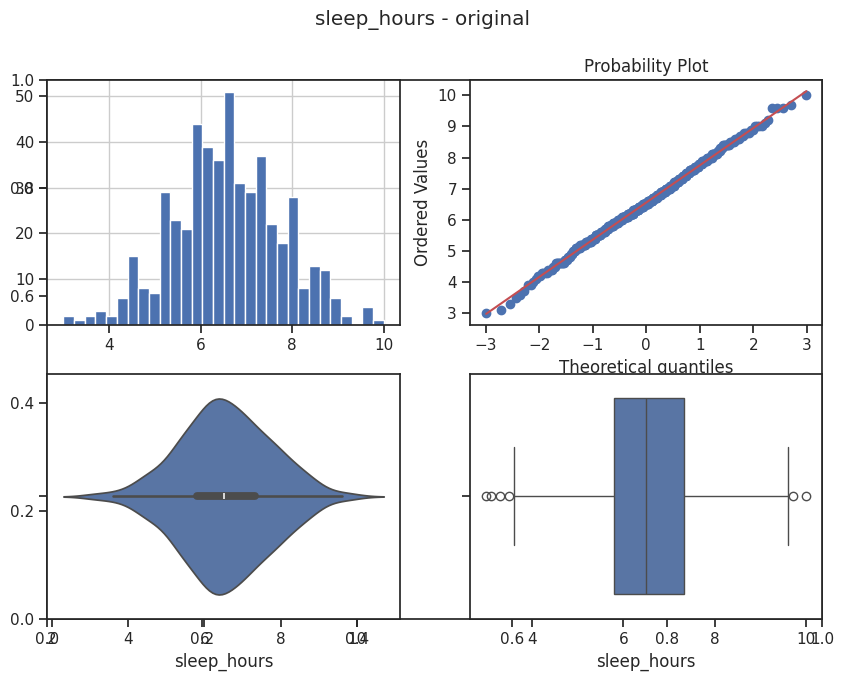

In [7]:
# diagnostic_plots(data, 'Age', 'Age - original')
diagnostic_plots(data, 'sleep_hours', 'sleep_hours - original')


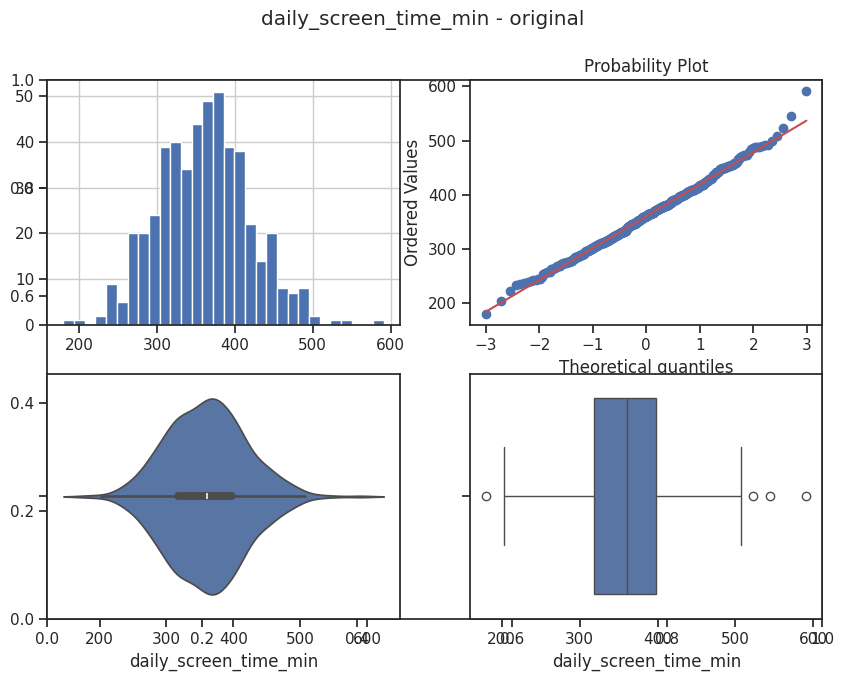

In [8]:
# diagnostic_plots(data, 'Positive Feedback Count', 'Positive Feedback Count - original')
diagnostic_plots(data, 'daily_screen_time_min', 'daily_screen_time_min - original')

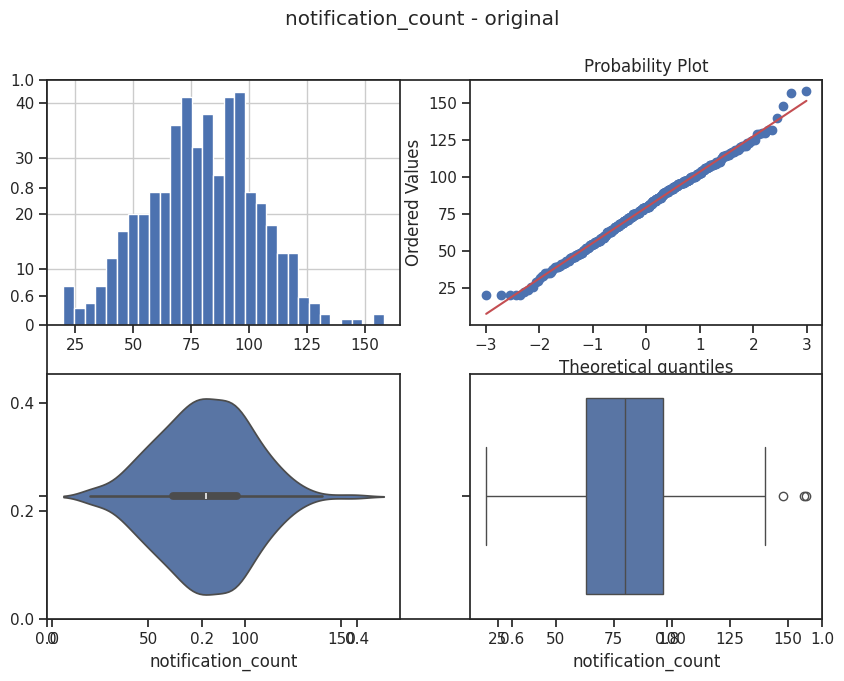

In [9]:
diagnostic_plots(data, 'notification_count', 'notification_count - original')


# Работа с выбросами

## Обнаружение выбросов

По определению гистограммы распределения, выбросы - это значения на краях гистограммы (очень большие или очень маленькие по сравнению со всей выборкой).

Задача обнаружения выбросов - это задача выделения элементов, находящихся на краях гистограммы.

Подход в случае нормального распределения

Или распределения, похожего на нормальное.

**Использование правила трех сигм**

$$ outlier < mean(x) - 3 \cdot std(x) $$
$$ outlier > mean(x) + 3 \cdot std(x) $$

где $ \sigma = std(x) $



**Использование 5% и 95% квантилей**

95% данных располагаются выше 5% квантиля и 95% данных располагаются ниже 95% квантиля. Значения ниже 5% квантиля и выше 95% квантиля можно считать выбросами.


**Использование межквартильного размаха**

Межквартильный размах IQR (interquartile range, IQR) - это разность третьего квартиля и первого квартиля:

$$ IQR = Q3(x) - Q1(x) $$

Тогда:

$$  outlier < Q1(x) - K \cdot IQR $$
$$  outlier > Q3(x) + K \cdot IQR $$

Значение $K$ обычно выбирается равным $1,5$.

In [10]:
# Тип вычисления верхней и нижней границы выбросов
from enum import Enum
class OutlierBoundaryType(Enum):
    SIGMA = 1
    QUANTILE = 2
    IRQ = 3

In [11]:
# Функция вычисления верхней и нижней границы выбросов
def get_outlier_boundaries(df, col, outlier_boundary_type: OutlierBoundaryType):
    if outlier_boundary_type == OutlierBoundaryType.SIGMA:
        K1 = 3
        lower_boundary = df[col].mean() - (K1 * df[col].std())
        upper_boundary = df[col].mean() + (K1 * df[col].std())

    elif outlier_boundary_type == OutlierBoundaryType.QUANTILE:
        lower_boundary = df[col].quantile(0.05)
        upper_boundary = df[col].quantile(0.95)

    elif outlier_boundary_type == OutlierBoundaryType.IRQ:
        K2 = 1.5
        IQR = df[col].quantile(0.75) - df[col].quantile(0.25)
        lower_boundary = df[col].quantile(0.25) - (K2 * IQR)
        upper_boundary = df[col].quantile(0.75) + (K2 * IQR)

    else:
        raise NameError('Unknown Outlier Boundary Type')

    return lower_boundary, upper_boundary

## Устранение выбросов

- Устранение предполагает удаление или замену выбросов.
- Для замены могут использоваться найденные верхняя и нижняя границы.
- Найденные выбросы можно считать "псевдо-пропущенными значениями" и использовать для их замены методы обработки пропусков.

In [12]:
data.shape
# x_col_list = ['Age', 'Positive Feedback Count'] # Для набора данных про одежду
x_col_list = ['sleep_hours', 'daily_screen_time_min', 'notification_count'] # Для набора данных с ментальным здоровьем


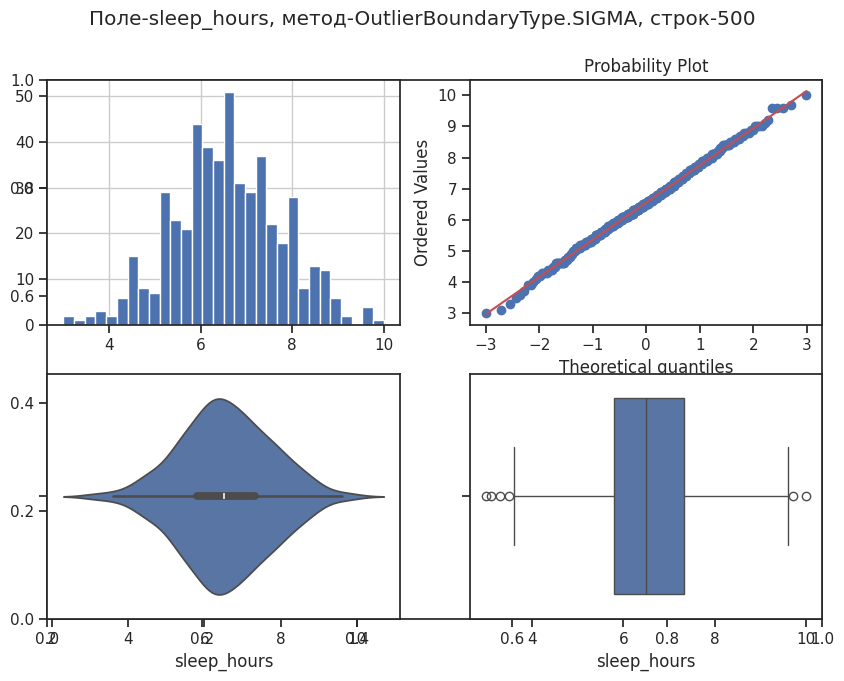

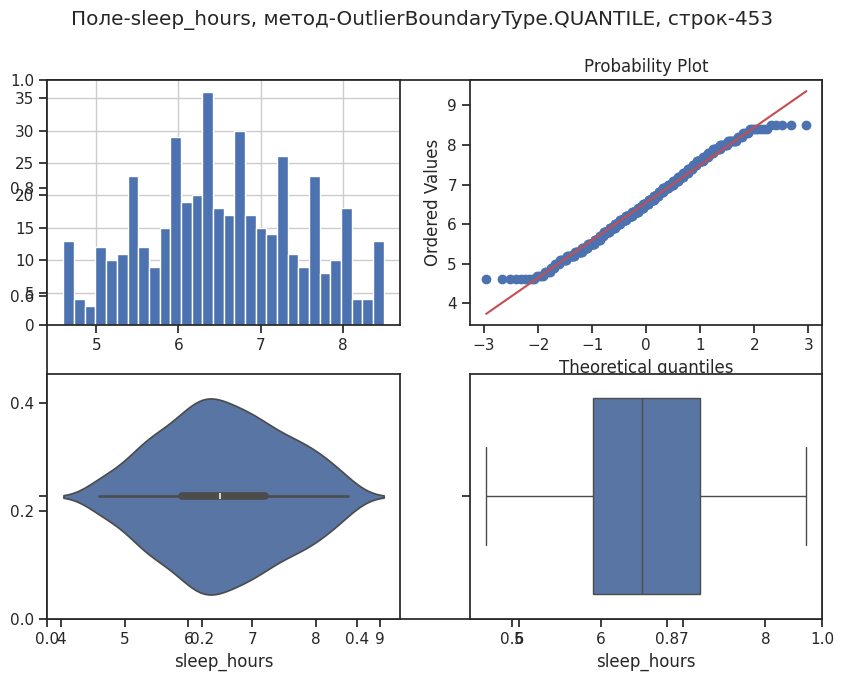

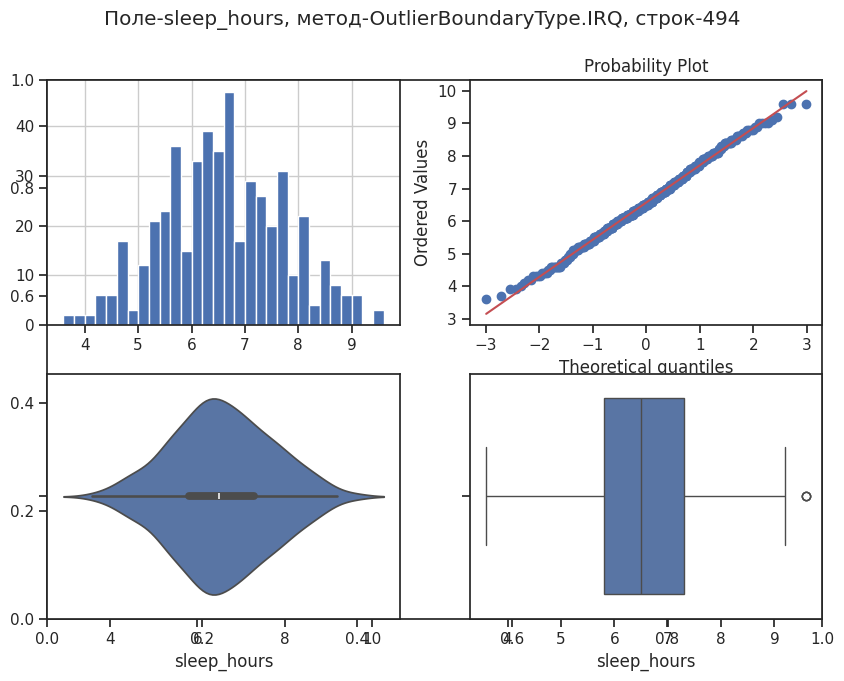

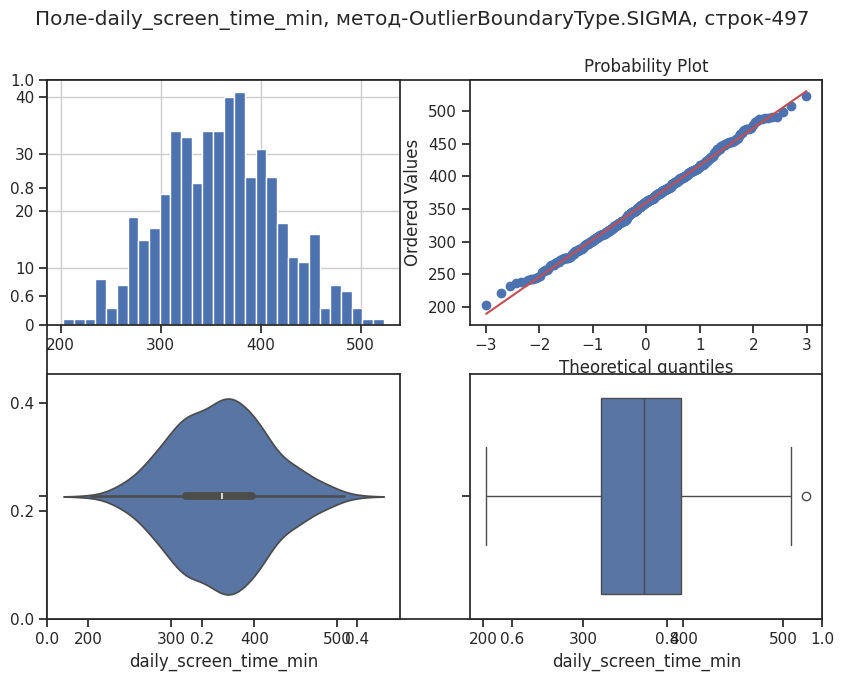

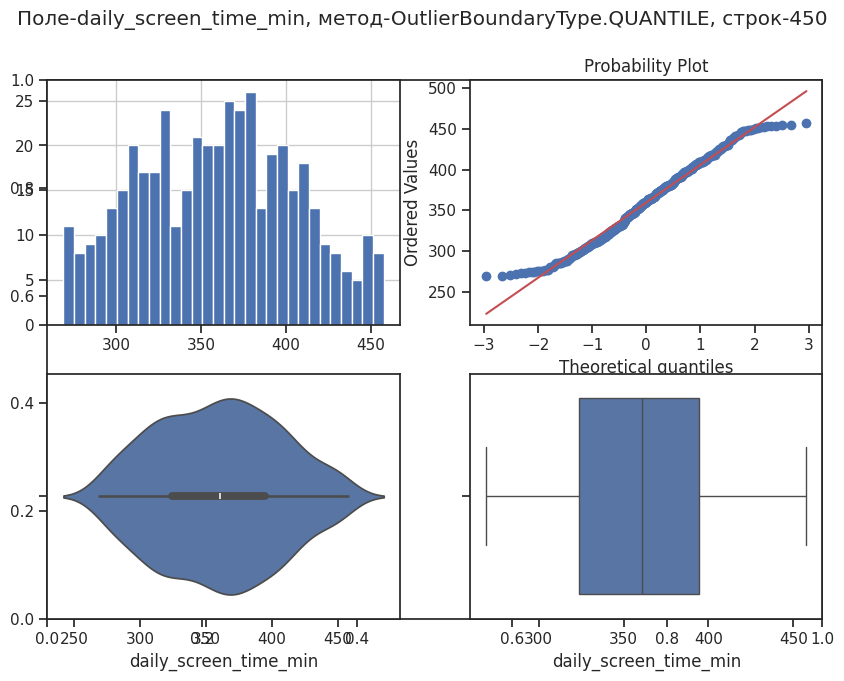

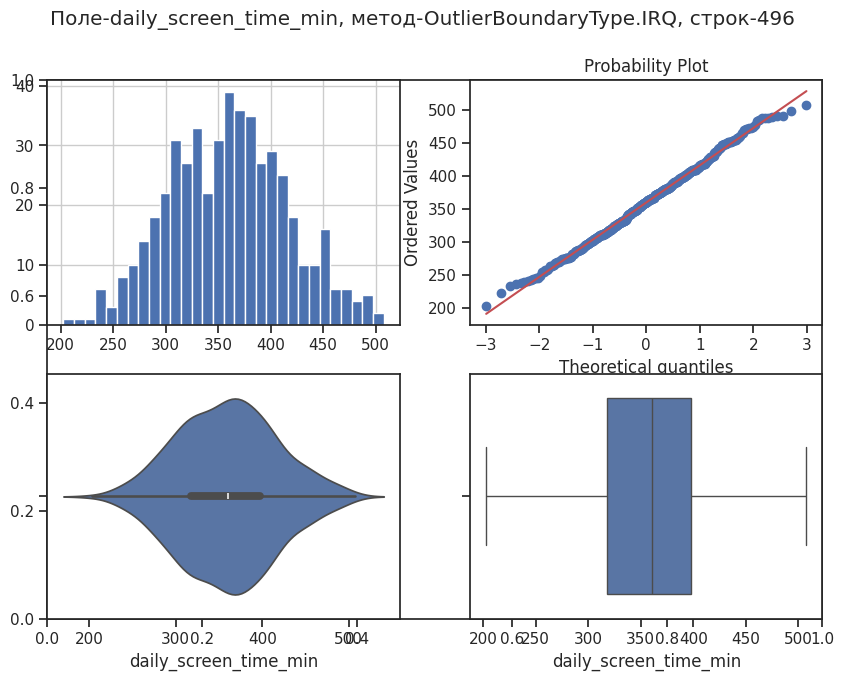

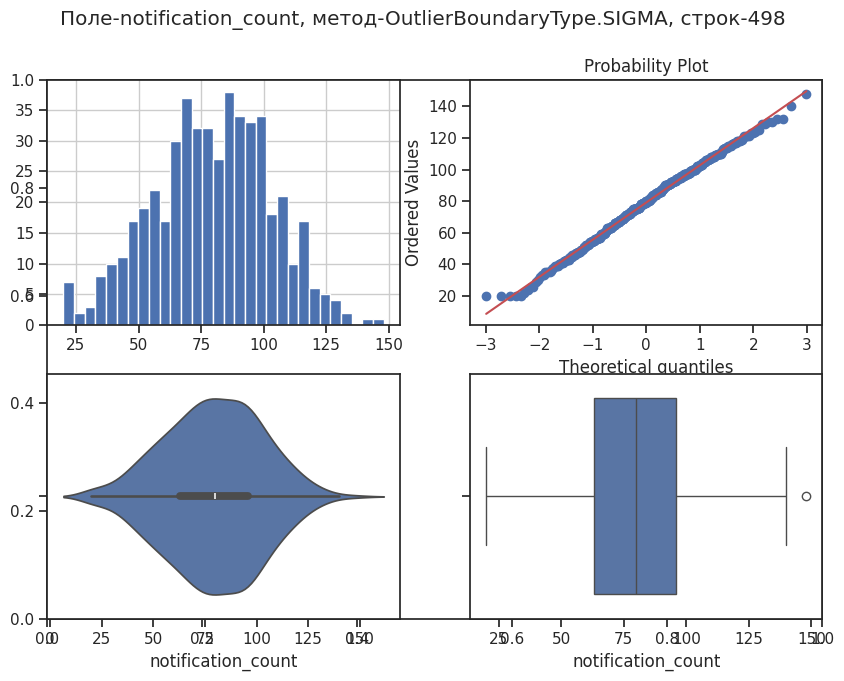

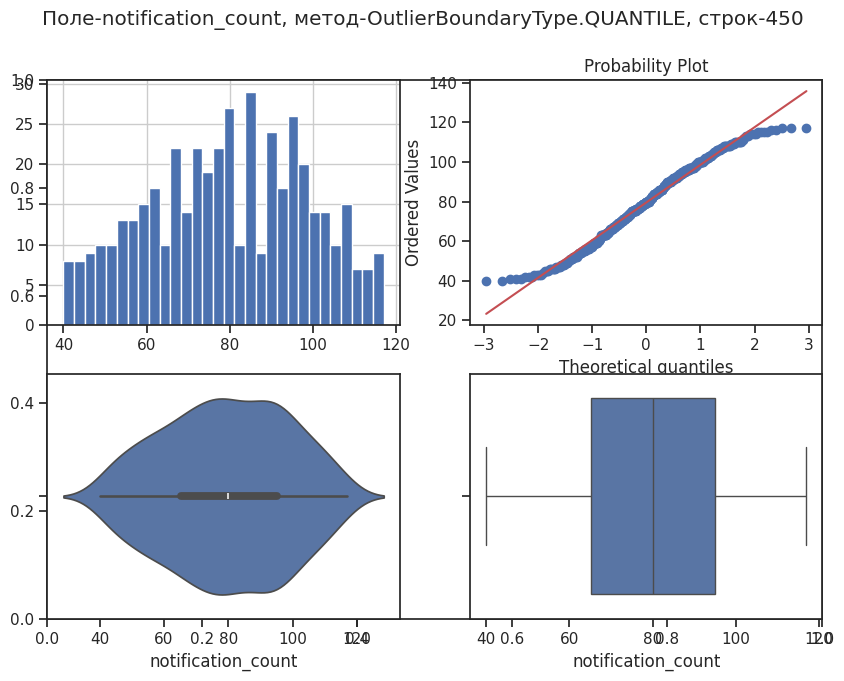

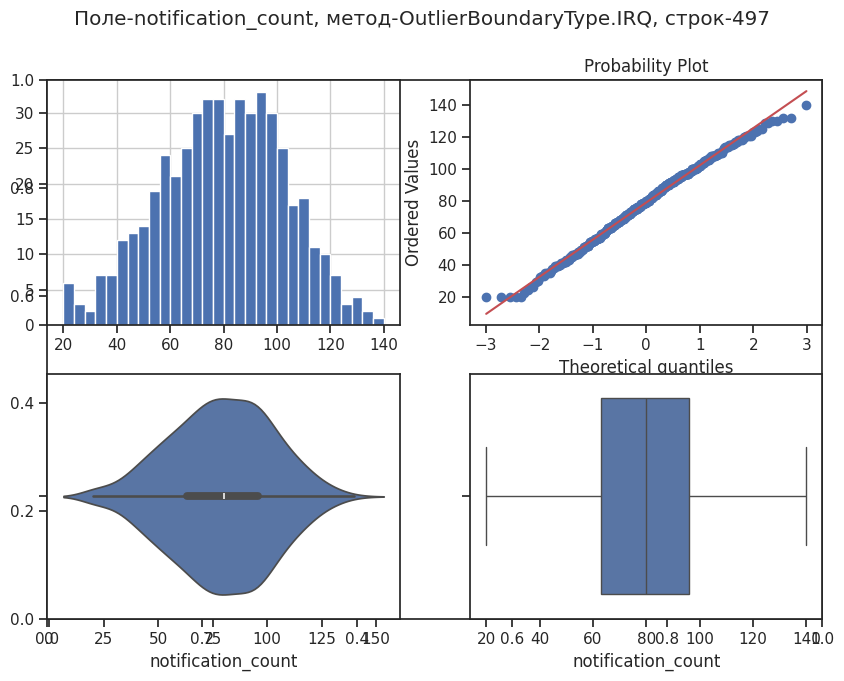

In [13]:
for col in x_col_list:
    for obt in OutlierBoundaryType:
        # Вычисление верхней и нижней границы
        lower_boundary, upper_boundary = get_outlier_boundaries(data, col, obt)
        # Флаги для удаления выбросов
        outliers_temp = np.where(data[col] > upper_boundary, True,
                                 np.where(data[col] < lower_boundary, True, False))
        # Удаление данных на основе флага
        data_trimmed = data.loc[~(outliers_temp), ]
        title = 'Поле-{}, метод-{}, строк-{}'.format(col, obt, data_trimmed.shape[0])
        diagnostic_plots(data_trimmed, col, title)

## Замена выбросов

Для замены используем найденные верхнюю и нижнюю границы.

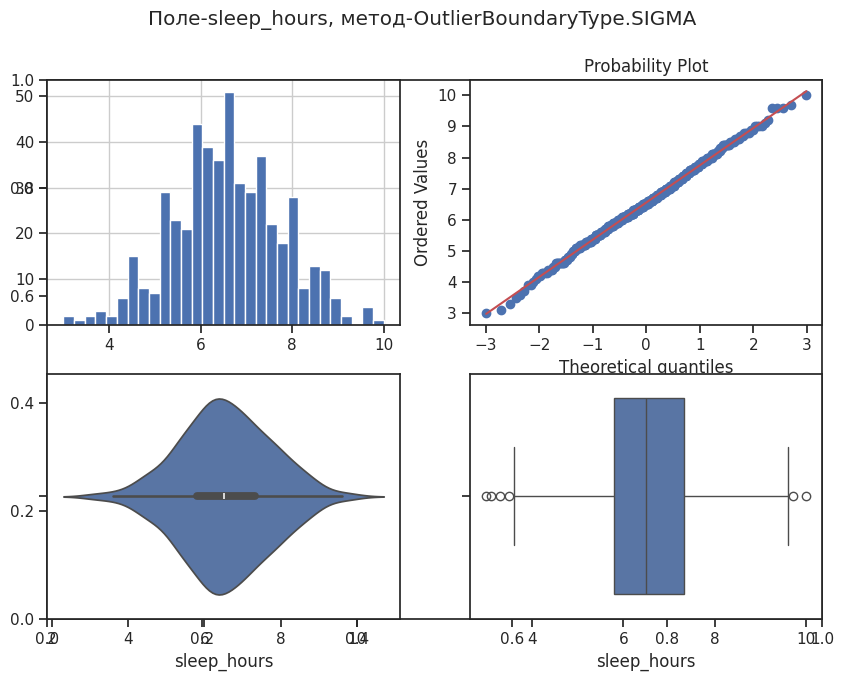

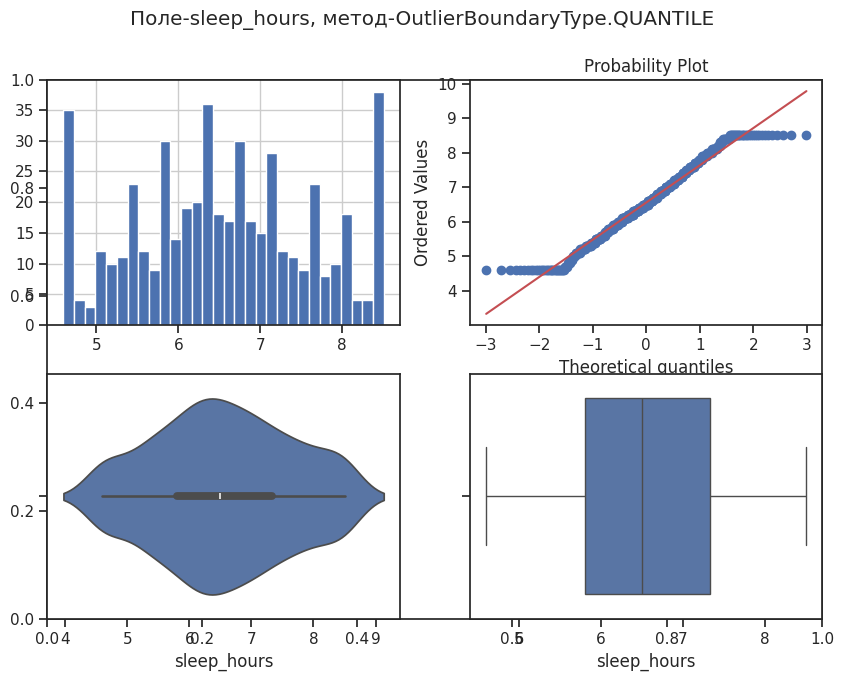

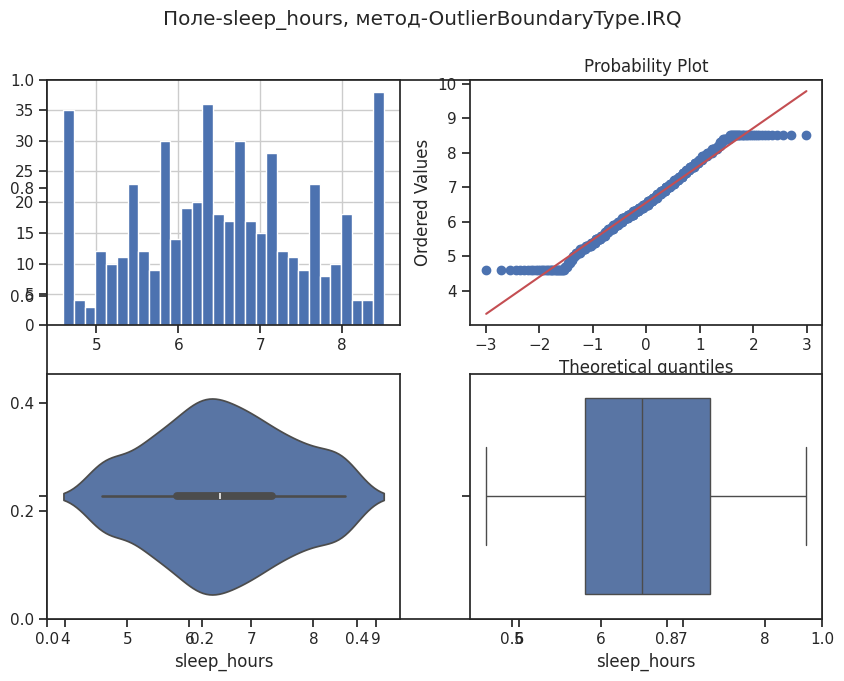

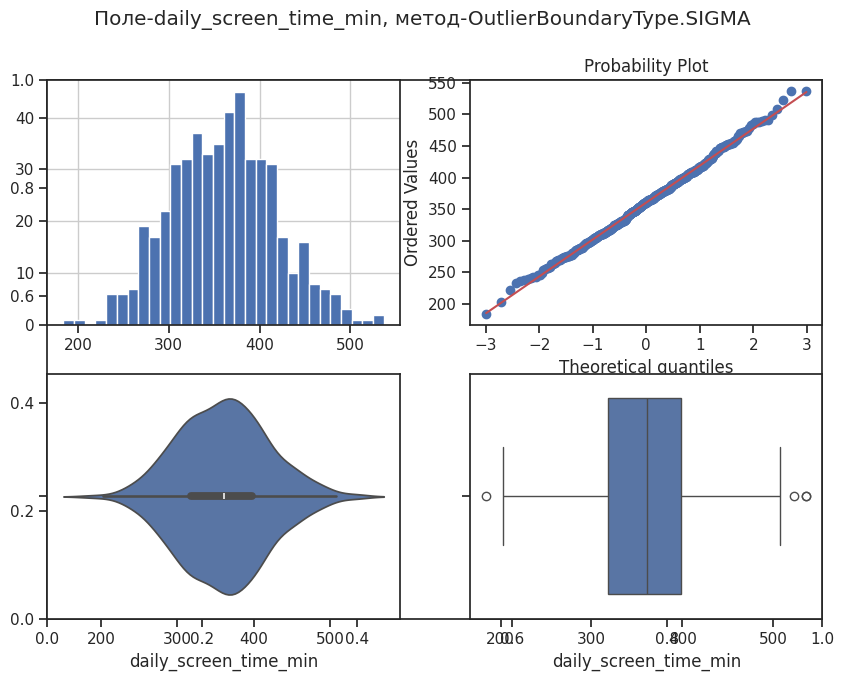

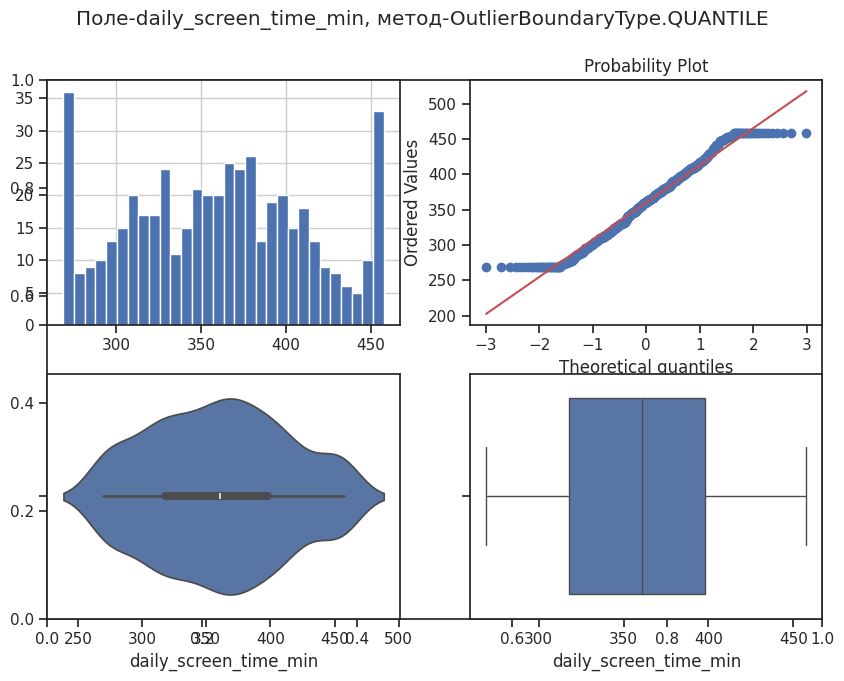

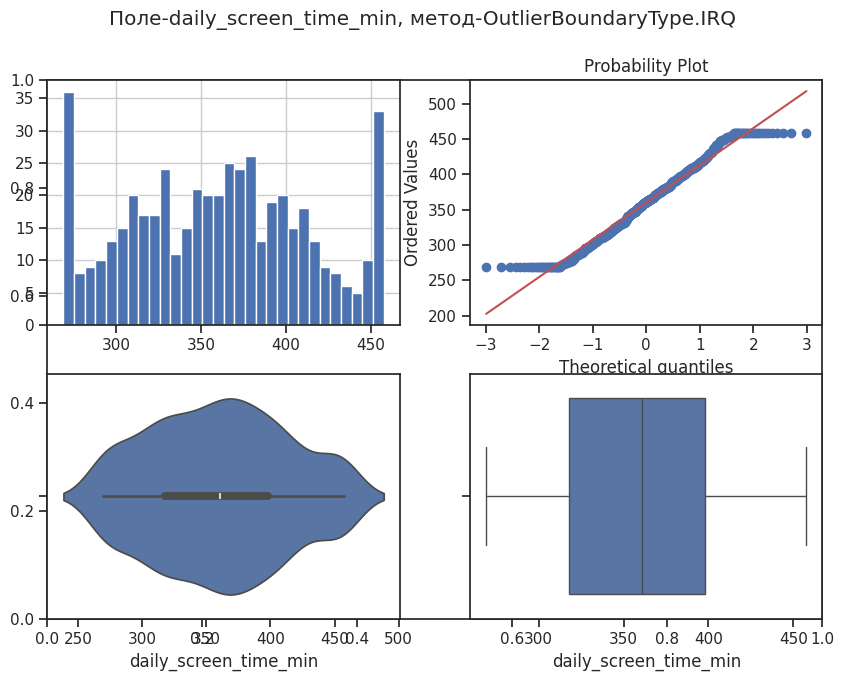

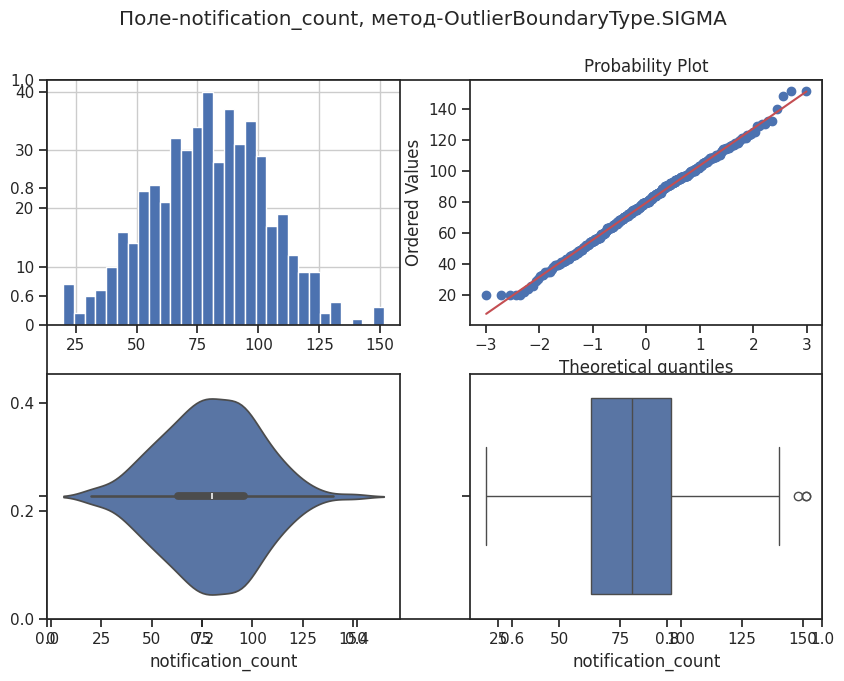

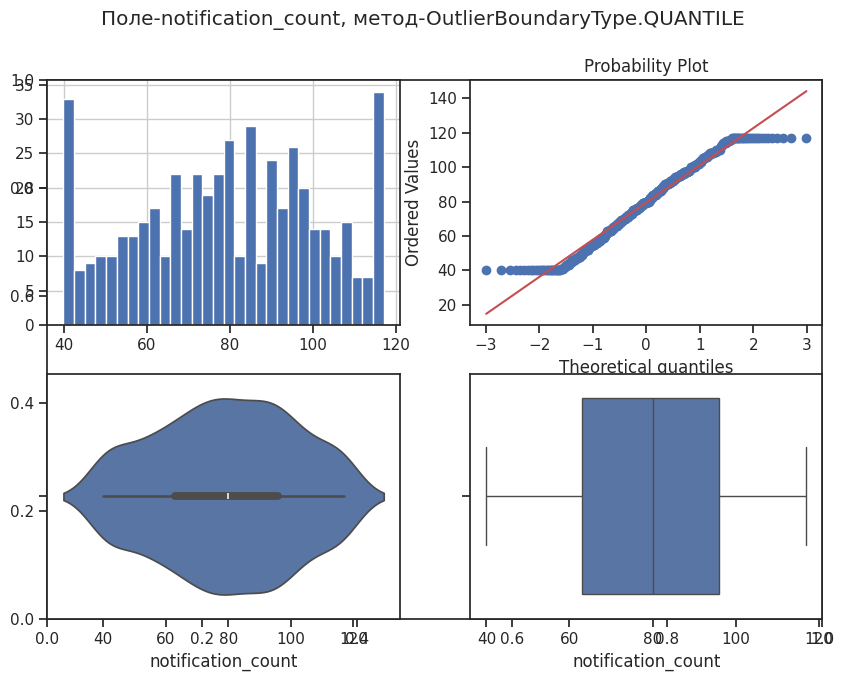

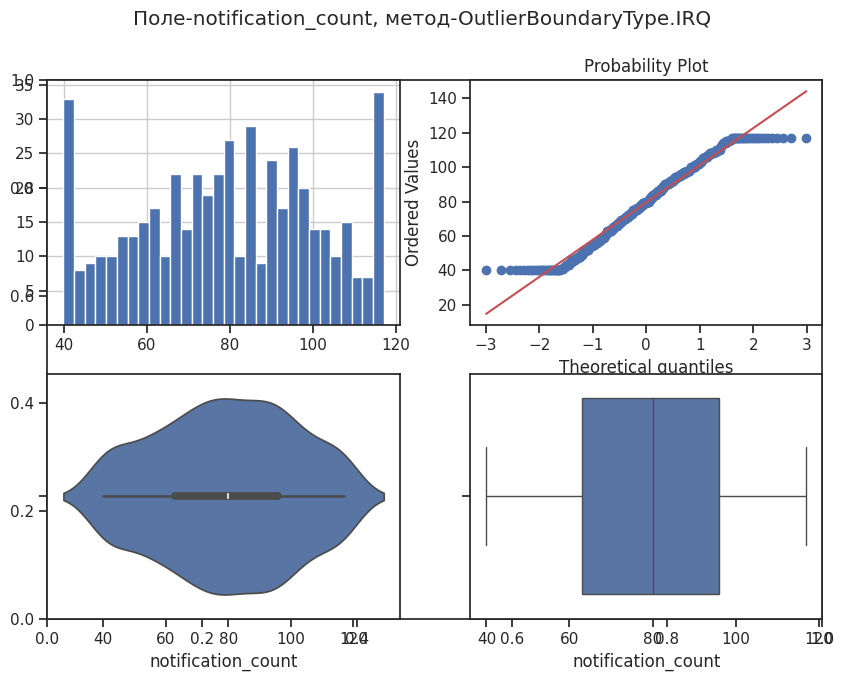

In [14]:
for col in x_col_list:
    for obt in OutlierBoundaryType:
        # Вычисление верхней и нижней границы
        lower_boundary, upper_boundary = get_outlier_boundaries(data, col, obt)
        # Изменение данных
        data[col] = np.where(data[col] > upper_boundary, upper_boundary,
                                 np.where(data[col] < lower_boundary, lower_boundary, data[col]))
        title = 'Поле-{}, метод-{}'.format(col, obt)
        diagnostic_plots(data, col, title)

# Обучение моделей с различными вариантами обработки выбросов

Одной из наиболее чувствительных к выбросам моделей является машина опорных векторов.

Обработка выбросов должна производиться **ТОЛЬКО В ОБУЧАЮЩЕЙ ВЫБОРКЕ**, чтобы улучшить точность построения модели.

In [15]:
class MetricLogger:

    def __init__(self):
        self.df = pd.DataFrame(
            {'metric': pd.Series([], dtype='str'),
            'alg': pd.Series([], dtype='str'),
            'value': pd.Series([], dtype='float')})

    def add(self, metric, alg, value):
        """
        Добавление значения
        """
        # Удаление значения если оно уже было ранее добавлено
        self.df.drop(self.df[(self.df['metric']==metric)&(self.df['alg']==alg)].index, inplace = True)
        # Добавление нового значения
        # temp = [{'metric':metric, 'alg':alg, 'value':value}]
        temp = pd.DataFrame({'metric':[metric], 'alg':[alg], 'value':[value]})
        # self.df = self.df.append(temp, ignore_index=True)
        self.df = pd.concat([self.df, temp], ignore_index=False)

    def get_data_for_metric(self, metric, ascending=True):
        """
        Формирование данных с фильтром по метрике
        """
        temp_data = self.df[self.df['metric']==metric]
        temp_data_2 = temp_data.sort_values(by='value', ascending=ascending)
        return temp_data_2['alg'].values, temp_data_2['value'].values

    def plot(self, str_header, metric, ascending=True, figsize=(5, 5)):
        """
        Вывод графика
        """
        array_labels, array_metric = self.get_data_for_metric(metric, ascending)
        fig, ax1 = plt.subplots(figsize=figsize)
        pos = np.arange(len(array_metric))
        rects = ax1.barh(pos, array_metric,
                         align='center',
                         height=0.5,
                         tick_label=array_labels)
        ax1.set_title(str_header)
        for a,b in zip(pos, array_metric):
            plt.text(0.5, a-0.05, str(round(b,3)), color='white')
        plt.show()

In [16]:
# DataFrame не содержащий целевой признак
# X_ALL = data.drop('Rating', axis=1) # Для набора данных одежды
X_ALL = data.drop('digital_wellbeing_score', axis=1) # Для набора данных ментального здоровья


# Разделим выборку на обучающую и тестовую
# Для набора данных одежды
# X_train, X_test, y_train, y_test = train_test_split(X_ALL, data['Rating'],
#                                                     test_size=0.2,
#                                                     random_state=1)



# Для набора данных ментального здоровья
X_train, X_test, y_train, y_test = train_test_split(X_ALL, data['digital_wellbeing_score'],
                                                    test_size=0.2,
                                                    random_state=1)


# Преобразуем массивы в DataFrame
X_train_df = pd.DataFrame(X_train, columns=X_ALL.columns)
X_test_df = pd.DataFrame(X_test, columns=X_ALL.columns)

X_train_df.shape, X_test_df.shape

((400, 8), (100, 8))

In [17]:
# Список методов обработки выбросов
method_list = ['Original']

# Список наборов данных
x_train_list = [X_train_df]
y_train_list = [y_train]

#### Для набора данных про одежду

In [18]:
# # Удаление выбросов
# for obt in OutlierBoundaryType:

#     df1 = X_train_df.copy()
#     df1['Rating'] = y_train

#     # Вычисление верхней и нижней границы
#     Age_lower_boundary, Age_upper_boundary = get_outlier_boundaries(df1, 'Age', obt)
#     Feedback_lower_boundary, Feedback_upper_boundary = get_outlier_boundaries(df1, 'Positive Feedback Count', obt)

#     # Флаги для удаления выбросов
#     outliers_Age = np.where(df1['Age'] > Age_upper_boundary, True,
#                              np.where(df1['Age'] < Age_lower_boundary, True, False))
#     outliers_Feedback = np.where(df1['Positive Feedback Count'] > Feedback_upper_boundary, True,
#                              np.where(df1['Positive Feedback Count'] < Feedback_lower_boundary, True, False))

#     # Изменение данных
#     data_train_trimmed = df1.loc[~(outliers_Age + outliers_Feedback), ]
#     x_data_train_trimmed = data_train_trimmed.drop('Rating', axis=1)
#     y_data_train_trimmed = data_train_trimmed['Rating']
#     title = '{}-trimmed'.format(obt)
#     # Сохранение в списки
#     method_list.append(title)
#     x_train_list.append(x_data_train_trimmed)
#     y_train_list.append(y_data_train_trimmed)

#### Для набора данных про ментальное здоровье

In [19]:
# Удаление выбросов
for obt in OutlierBoundaryType:

    df1 = X_train_df.copy()
    df1['digital_wellbeing_score'] = y_train


    # Вычисление верхней и нижней границы
    sleep_hours_lower_boundary, sleep_hours_upper_boundary = get_outlier_boundaries(df1, 'sleep_hours', obt)
    screen_time_lower_boundary, screen_time_upper_boundary = get_outlier_boundaries(df1, 'daily_screen_time_min', obt)
    notification_count_lower_boundary, notification_count_upper_boundary = get_outlier_boundaries(df1, 'notification_count', obt)

    # Флаги для удаления выбросов
    outliers_sleep_hours = np.where(df1['sleep_hours'] > sleep_hours_upper_boundary, True,
                             np.where(df1['sleep_hours'] < sleep_hours_lower_boundary, True, False))
    outliers_screen_time = np.where(df1['daily_screen_time_min'] > screen_time_upper_boundary, True,
                             np.where(df1['daily_screen_time_min'] < screen_time_lower_boundary, True, False))
    outliers_notification_count = np.where(df1['notification_count'] > notification_count_upper_boundary, True,
                             np.where(df1['notification_count'] < notification_count_lower_boundary, True, False))

    # Изменение данных
    data_train_trimmed = df1.loc[~(outliers_sleep_hours + outliers_screen_time + outliers_notification_count), ]
    x_data_train_trimmed = data_train_trimmed.drop('digital_wellbeing_score', axis=1)
    y_data_train_trimmed = data_train_trimmed['digital_wellbeing_score']
    title = '{}-trimmed'.format(obt)
    # Сохранение в списки
    method_list.append(title)
    x_train_list.append(x_data_train_trimmed)
    y_train_list.append(y_data_train_trimmed)

In [20]:
clas_models_dict = {'LinR': LinearRegression(),
                    'SVR': SVR(),
                    'KNN_5':KNeighborsRegressor(n_neighbors=5),
                    'Tree':DecisionTreeRegressor(random_state=1),
                    'GB': GradientBoostingRegressor(random_state=1),
                    'RF':RandomForestRegressor(n_estimators=50, random_state=1)}

In [21]:
def test_models(clas_models_dict, method_list, x_train_list, y_train_list, X_test, y_test):
    logger = MetricLogger()
    for model_name, model in clas_models_dict.items():
        for name, (x_data, y_data) in zip(method_list, zip(x_train_list, y_train_list)):
            model.fit(x_data, y_data)
            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)
            logger.add(model_name, name, mse)
    return logger

In [22]:
# data['Rating'] = pd.to_numeric(data['Rating'], errors='coerce')
# data['Rating'] = data['Rating'].astype(int)

In [23]:
%%time
logger = test_models(clas_models_dict, method_list, x_train_list, y_train_list, X_test, y_test)

CPU times: user 978 ms, sys: 7.05 ms, total: 985 ms
Wall time: 1 s


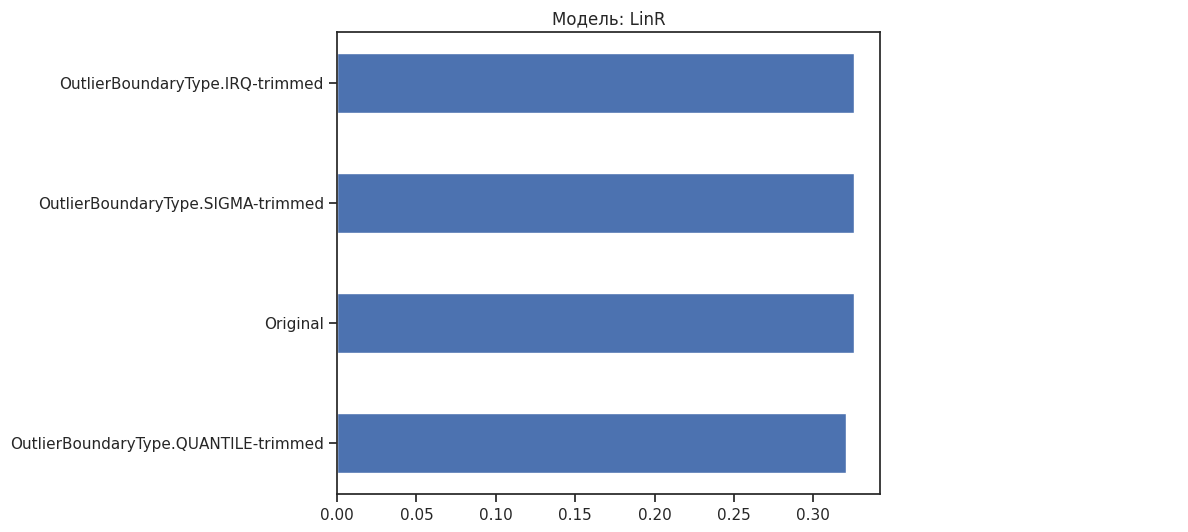

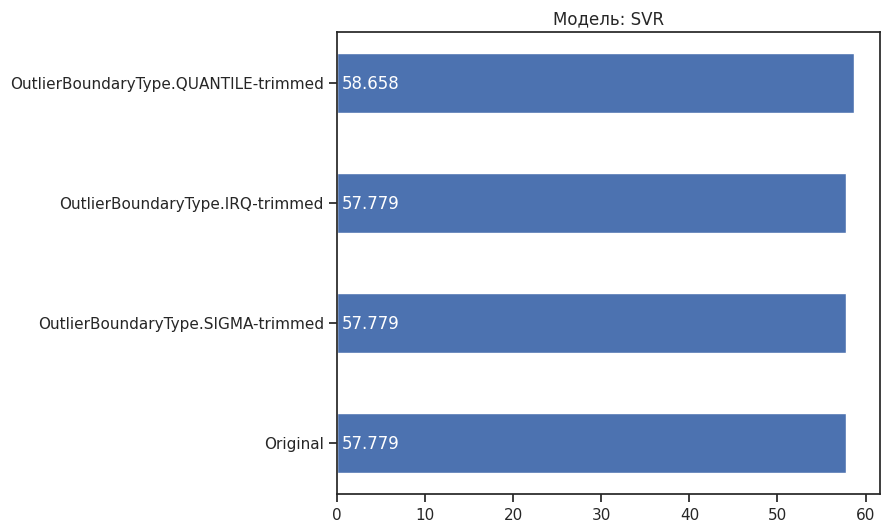

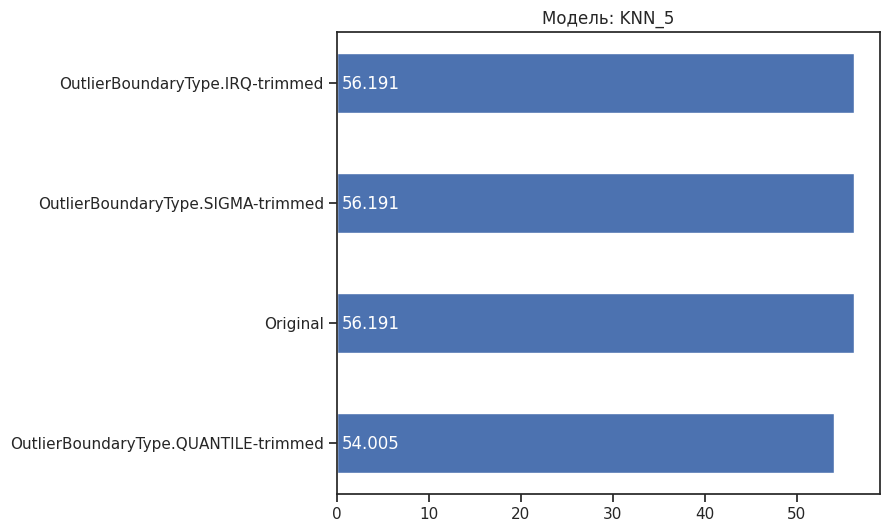

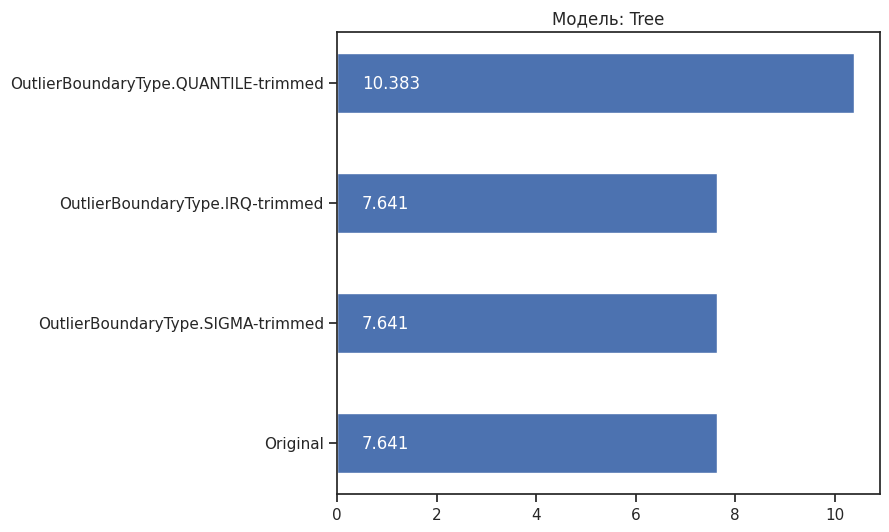

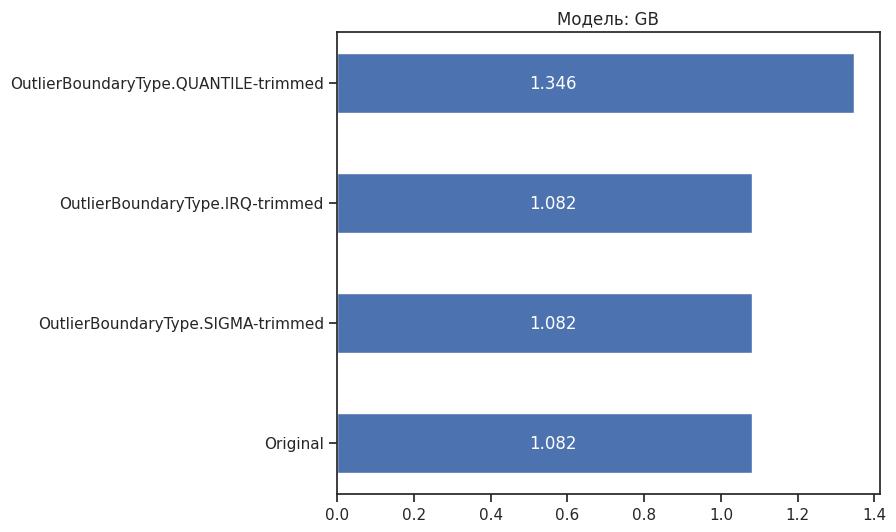

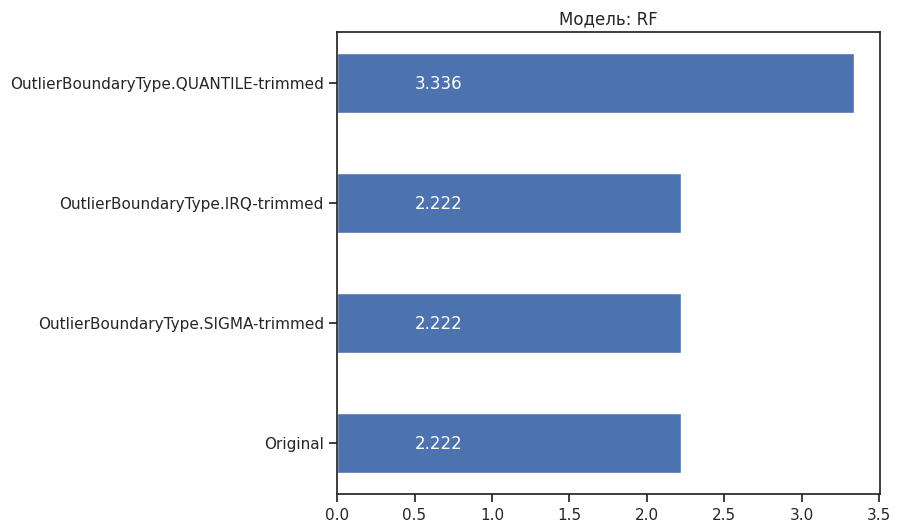

In [24]:
# Построим графики метрик качества модели
for model in clas_models_dict:
    logger.plot('Модель: ' + model, model, figsize=(7, 6))

# Отбор признаков (Feature Selection)

## Четыре группы методов отбора признаков:

1. Методы фильтрации (filter methods).
1. Методы обертывания (wrapper methods).
1. Методы вложений (embedded methods).
1. Гибридные методы.

## Методы фильтрации (filter methods)

- Методы выбирают наиболее "подходящие" признаки без использования моделей машинного обучения на основе статистических характеристик выборки (корреляция и т.д.)
- Наименее затратны с точки зрения вычислительных ресурсов.
- Могут уступать другим методам по качеству отбора признаков, потому что не учитывают зависимости между признаками.
- Хорошо подходят для начальной фильтрации признаков.

### Простейшие методы фильтрации

#### Удаление константных и псевдоконстантных (почти константных) признаков

- Если признак содержит одинаковые (константные) значения, то он не может внести вклад в построение модели.
- Если признак содержит почти все одинаковые (константные) значения, то скорее всего он мало полезен при построении модели. (При этом нужно быть осторожным, так как данный признак может быть индикатором одного из классов в случае классификации).
- Для поиска таких признаков можно использовать функцию `unique()`.
- Но удобнее использовать дисперсию:
    - У константного признака нулевая дисперсия.
    - У псевдоконстантного списка значение дисперсии очень мало.
- Возможно использование класса [VarianceThreshold](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.VarianceThreshold.html) из библиотеки Sklearn.

In [27]:
from sklearn.feature_selection import VarianceThreshold

# Создание объекта VarianceThreshold с порогом 0.01 (удаление признаков с крайне низкой дисперсией)
# Порог (threshold) можно настроить в зависимости от данных и требуемой строгости.
# threshold=0 удаляет только строго константные признаки.
# threshold=0.02 удаляет признаки, где 98% значений одинаковы (например, для бинарных признаков).
selector = VarianceThreshold(threshold=0.02)

# Применение к данным
selector.fit(X_ALL)

# Получение маски для выбранных признаков
features_mask = selector.get_support()

# Получение имен выбранных признаков
selected_features = X_ALL.columns[features_mask]

# Получение имен удаленных признаков
removed_features = X_ALL.columns[~features_mask]

print("Отобранные признаки (не константные и не псевдоконстантные):")
print(selected_features)
print("\nУдаленные признаки (константные или псевдоконстантные):")
print(removed_features)

Отобранные признаки (не константные и не псевдоконстантные):
Index(['daily_screen_time_min', 'num_app_switches', 'sleep_hours',
       'notification_count', 'social_media_time_min', 'focus_score',
       'mood_score', 'anxiety_level'],
      dtype='object')

Удаленные признаки (константные или псевдоконстантные):
Index([], dtype='object')


### Методы, основанные на корреляции

- Желательно, чтобы признаки хорошо коррелировали с целевым признаком.
- Важно, чтобы признаки не коррелировали между собой.

Признаки, коррелирующие с целевой переменной (порог > 0.3):
['anxiety_level', 'sleep_hours', 'focus_score', 'notification_count']

Признаки, удаленные из-за высокой междисперсионной корреляции (порог > 0.7):
set()

Финальный список отобранных признаков:
['anxiety_level', 'sleep_hours', 'focus_score', 'notification_count']


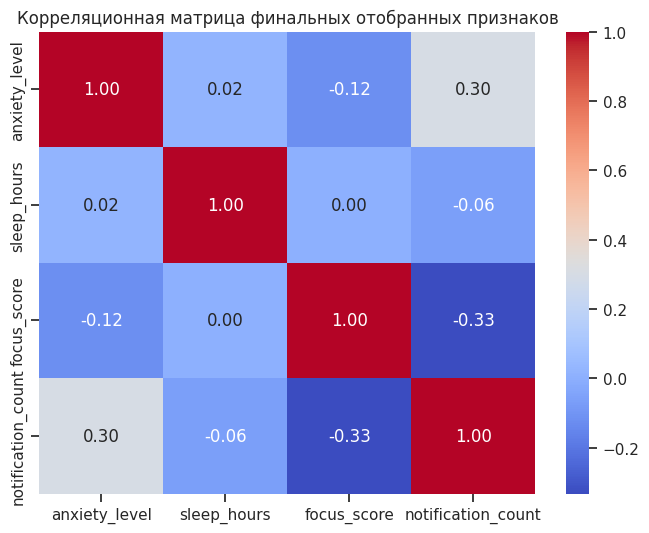

In [28]:
# 1. Объединение признаков и целевой переменной для расчета корреляции
df_corr = X_ALL.copy()
df_corr['target'] = data['digital_wellbeing_score']

# 2. Вычисление корреляции каждого признака с целевой переменной
correlation_with_target = df_corr.corr()['target'].abs().sort_values(ascending=False)

# Зададим порог для корреляции с целевой переменной
# (например, выбираем признаки, чья абсолютная корреляция с таргетом выше 0.3)
target_corr_threshold = 0.3
relevant_features = correlation_with_target[correlation_with_target > target_corr_threshold].index.tolist()

# Исключаем сам таргет из списка признаков, если он там оказался
if 'target' in relevant_features:
    relevant_features.remove('target')

print(f"Признаки, коррелирующие с целевой переменной (порог > {target_corr_threshold}):\n{relevant_features}")

# 3. Вычисление корреляционной матрицы для отобранных признаков
corr_matrix = df_corr[relevant_features].corr().abs()

# 4. Удаление признаков, сильно коррелирующих между собой
# Зададим порог для междисперсионной корреляции (например, если корреляция > 0.7, удаляем один из признаков)
inter_feature_corr_threshold = 0.7

# Создаем набор признаков для удаления
features_to_remove = set()

# Итерируемся по верхней треугольной части матрицы корреляции
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > inter_feature_corr_threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]

            # Определяем, какой из двух коррелирующих признаков менее важен (менее коррелирует с таргетом)
            if correlation_with_target[col1] < correlation_with_target[col2]:
                features_to_remove.add(col1)
            else:
                features_to_remove.add(col2)

# Создаем список конечных выбранных признаков
final_selected_features = [feature for feature in relevant_features if feature not in features_to_remove]

print(f"\nПризнаки, удаленные из-за высокой междисперсионной корреляции (порог > {inter_feature_corr_threshold}):\n{features_to_remove}")
print(f"\nФинальный список отобранных признаков:\n{final_selected_features}")

# Визуализация корреляционной матрицы для финальных признаков
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[final_selected_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица финальных отобранных признаков')
plt.show()


В реальной модели могут быть сотни признаков и коррелирующие признаки могут образовывать группы, состояшие более чем из  двух признаков. Увидеть такие группы с помощью тепловой карты сложно.

Для решения задачи предлагается новый вариант визуализации - "Солнечная корреляционная карта" [Solar correlation map](https://github.com/Zapf-Consulting/solar-correlation-map).

К сожалению, данная библиотека пока работает только через файловый интерфейс и не предназначена для встраивания в ноутбук.

Примеры статей с описанием работы библиотеки:
- https://www.oreilly.com/learning/a-new-visualization-to-beautifully-explore-correlations
- https://www.mtab.com/the-puzzle-of-visualizing-correlations/

### [Методы, основанные на статистических характеристиках (univariate feature selection)](https://scikit-learn.org/stable/modules/feature_selection.html#univariate-feature-selection)

Используются классы:
- SelectKBest, который выбирает К лучших признаков
- SelectPercentile, который выбирает К процентов лучших признаков

Основным параметром конструктора классов является функция, которая принимает X и y, и возвращает оценки (scores), и [уровни значимости](https://ru.wikipedia.org/wiki/P-%D0%B7%D0%BD%D0%B0%D1%87%D0%B5%D0%BD%D0%B8%D0%B5) (pvalues).

В качестве таких функций используются:

1. Основанные на [взаимной информации](https://ru.wikipedia.org/wiki/%D0%92%D0%B7%D0%B0%D0%B8%D0%BC%D0%BD%D0%B0%D1%8F_%D0%B8%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D1%8F)
    - [mutual_info_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_classif.html) - для классификации
    - [mutual_info_regression](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_regression.html) - для регрессии

1. Другие:
    - [chi2](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.chi2.html) - для классификации
    - [f_classif](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_classif.html) - для классификации
    - [f_regression](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html) - для регрессии

In [29]:
from sklearn.feature_selection import SelectKBest, f_regression

# Инициализация SelectKBest для выбора K лучших признаков
# 'k' можно настроить. Здесь выбрано 4 признака, основываясь на предыдущем анализе корреляции.
# f_regression используется для регрессионных задач.
selector = SelectKBest(score_func=f_regression, k=4)

# Обучение селектора на тренировочных данных
selector.fit(X_train, y_train)

# Получение маски для выбранных признаков
features_mask_kbest = selector.get_support()

# Получение имен выбранных признаков
selected_features_kbest = X_train.columns[features_mask_kbest]

print("Отобранные признаки с использованием SelectKBest (k=4) и f_regression:")
print(selected_features_kbest)

# Можно также получить оценки (scores) для каждого признака
# feature_scores = pd.DataFrame({'Feature': X_train.columns, 'Score': selector.scores_})
# feature_scores = feature_scores.sort_values(by='Score', ascending=False)
# print("\nОценки важности признаков:")
# print(feature_scores)


Отобранные признаки с использованием SelectKBest (k=4) и f_regression:
Index(['sleep_hours', 'notification_count', 'focus_score', 'anxiety_level'], dtype='object')


## Методы обертывания (wrapper methods)

- Используют модели машинного обучения для отбора признаков.
- Формируют подмножества признаков.
- Для каждого подмножества признаков строится отдельная модель машинного обучения.
- Для конкретной модели машинного обучения (на которой производится оценка) чаще всего генерируют оптимальный набор признаков. (Но этот набор не обобщается на все модели.)
- Очень затратны с точки зрения вычислительных ресурсов.
- Могут приводить к переобучению моделей (особенно в случае маленьких выборок).

**Методы обертывания включают ["жадные"](https://ru.wikipedia.org/wiki/%D0%96%D0%B0%D0%B4%D0%BD%D1%8B%D0%B9_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC) алгоритмы трех видов:**

- Прямые алгоритмы (step forward feature selection или sequential forward selection) построены на постепенном добавлении новых признаков в модель.
- Обратные алгоритмы (step backwards feature selection или sequential backward selection) построены на постепенном удалении признаков из модели.
- Алгоритмы полного перебора (exhaustive feature selection) проверяют все возможные комбинации признаков.

Для решения задачи отбора признаков с помощью методов обертывания  может быть использована библиотека [MLxtend.](http://rasbt.github.io/mlxtend/)

### Прямые алгоритмы

- На первом шаге для каждого признака $x_i$ принадлежащего множеству признаков $X$ строятся модели машинного обучения (на основе одного признака). Оценивается качество всех моделей на основе заданной метрики, выбирается лучшая модель, содержащая один признак $x^1$.

- На втором шаге к признаку $x^1$ по очереди добавляются оставшиеся  признаки  $x_j$ принадлежащие множеству признаков $X$, и строятся модели машинного обучения (на основе двух признаков). Оценивается качество всех моделей на основе заданной метрики, выбирается лучшая модель из двух признаков.

- Процедура итеративно повторяется для 3, 4, ... признаков.

- Критерии остановки могут быть различными:
    - Улучшение метрики качества меньше заданной величины $\varepsilon$.
    - Выбрано $N$ лучших признаков.
    
Для решения задачи используется класс [Sequential Feature Selector](http://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector/) (с параметром конструктора `forward=True`) из библиотеки MLxtend.

### Обратные алгоритмы

- На первом шаге каждый признак $x_i$, принадлежащий множеству признаков $X$ удаляется из множества признаков, а для оставшихся признаков строятся модели машинного обучения. Оценивается качество всех моделей на основе заданной метрики, выбирается лучшая модель, содержащая все признаки, кроме одного $X^{-1}$.

- На втором шаге из множества $X^{-1}$ по очереди удаляется по одному из оставшихся  признаков  $x_j$ принадлежащих множеству признаков $X$, и строятся модели машинного обучения на основе исходного множества без двух признаков. Оценивается качество всех моделей на основе заданной метрики, выбирается лучшая модель, содержащая все признаки, кроме двух $X^{-2}$.

- Процедура итеративно повторяется с удалением третьего, четвертого  ... признаков.

- Критерии остановки могут быть различными:
    - Улучшение метрики качества меньше заданной величины $\varepsilon$.
    - В модели осталось (или из модели было удалено)  $N$ признаков.
    
Для решения задачи используется класс [Sequential Feature Selector](http://rasbt.github.io/mlxtend/user_guide/feature_selection/SequentialFeatureSelector/) (с параметром конструктора `forward=False`) из библиотеки MLxtend.

Для алгоритмов:
- sequential forward selection
- sequential backward selection

существуют их доработанные варианты

- sequential forward floating selection
- sequential backward floating selection

которые отличаются тем, что при некоторых условиях могут отменять добавление (или удаление) признака, если он ухудшает модель. Данная доработка далеко не всегда улучшает исходный алгоритм. Детали описаны в [статье.](https://www.researchgate.net/publication/221907632_Efficient_Feature_Subset_Selection_and_Subset_Size_Optimization)

### Алгоритмы полного перебора

- Осуществляют перебор всех комбинаций из 1, 2, ... N признаков.
- Для каждой комбинации строится модель и оценивается метрика качества.
- Выбирается лучшая модель на основе метрики.
- По сравнению с предыдущими двумя подходами, данный подход наиболее требователен к ресурсам.

Для решения задачи используется класс [ExhaustiveFeatureSelector](http://rasbt.github.io/mlxtend/user_guide/feature_selection/ExhaustiveFeatureSelector/) из библиотеки MLxtend.

Параметры min_features и max_features используются для задания диапазона количества перебираемых признаков.

In [30]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, make_scorer

# Define the estimator (Linear Regression)
lr = LinearRegression()

# Define the scoring metric (for regression, we often minimize MSE)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# --- Sequential Forward Selection (SFS) ---
print("\n--- Sequential Forward Selection (SFS) ---")
sfs = SFS(lr,
          k_features=4, # Number of features to select
          forward=True, # Forward selection
          floating=False,
          scoring=mse_scorer, # Scoring metric
          cv=2, # Cross-validation folds
          n_jobs=-1) # Use all available cores

sfs.fit(X_train, y_train)

print('\nSelected features (SFS):')
print(sfs.k_feature_names_)
print(f'MSE (SFS): {-sfs.k_score_:.4f}')

# To get the feature indices
# print('Selected feature indices (SFS):', sfs.k_feature_idx_)

# You can transform your data to include only the selected features
X_train_sfs = sfs.transform(X_train)
X_test_sfs = sfs.transform(X_test)

print('\nShape of X_train after SFS:', X_train_sfs.shape)
print('Shape of X_test after SFS:', X_test_sfs.shape)


# --- Sequential Backward Selection (SBS) ---
print("\n--- Sequential Backward Selection (SBS) ---")
sbs = SFS(lr,
          k_features=4, # Number of features to select
          forward=False, # Backward selection
          floating=False,
          scoring=mse_scorer, # Scoring metric
          cv=2, # Cross-validation folds
          n_jobs=-1) # Use all available cores

sbs.fit(X_train, y_train)

print('\nSelected features (SBS):')
print(sbs.k_feature_names_)
print(f'MSE (SBS): {-sbs.k_score_:.4f}')

# You can transform your data to include only the selected features
X_train_sbs = sbs.transform(X_train)
X_test_sbs = sbs.transform(X_test)

print('\nShape of X_train after SBS:', X_train_sbs.shape)
print('Shape of X_test after SBS:', X_test_sbs.shape)


# --- Exhaustive Feature Selector (EFS) ---
print("\n--- Exhaustive Feature Selector (EFS) ---")
from mlxtend.feature_selection import ExhaustiveFeatureSelector as EFS

efs = EFS(lr,
          min_features=2, # Minimum number of features to select
          max_features=3, # Maximum number of features to select (limited for demonstration)
          scoring=mse_scorer, # Scoring metric
          cv=2, # Cross-validation folds
          n_jobs=-1) # Use all available cores

efs.fit(X_train, y_train)

print('\nBest features (EFS):')
print(efs.best_feature_names_)
print(f'MSE (EFS): {-efs.best_score_:.4f}')

X_train_efs = efs.transform(X_train)
X_test_efs = efs.transform(X_test)

print('\nShape of X_train after EFS:', X_train_efs.shape)
print('Shape of X_test after EFS:', X_test_efs.shape)


--- Sequential Forward Selection (SFS) ---

Selected features (SFS):
('sleep_hours', 'focus_score', 'mood_score', 'anxiety_level')
MSE (SFS): 0.3606

Shape of X_train after SFS: (400, 4)
Shape of X_test after SFS: (100, 4)

--- Sequential Backward Selection (SBS) ---

Selected features (SBS):
('sleep_hours', 'focus_score', 'mood_score', 'anxiety_level')
MSE (SBS): 0.3606

Shape of X_train after SBS: (400, 4)
Shape of X_test after SBS: (100, 4)

--- Exhaustive Feature Selector (EFS) ---


Features: 84/84


Best features (EFS):
('sleep_hours', 'focus_score', 'anxiety_level')
MSE (EFS): 0.3607

Shape of X_train after EFS: (400, 3)
Shape of X_test after EFS: (100, 3)


## Методы вложений (embedded methods)

- Являются гибридом фильтрации и обертывания.
- Осуществляют отбор признаков на основе оценки важности признаков в процессе конструирования модели.
- По сравнению с методами обертывания, менее затратны с точки зрения вычислительных ресурсов.

In [31]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# --- 1. Discretize the target variable for classification demonstration ---
# The original 'digital_wellbeing_score' is continuous. To demonstrate
# embedded methods for classification, we'll discretize it into 3 classes.
# You might choose a different number of bins or a different method (e.g., fixed thresholds)
# based on domain knowledge if this were a real classification problem.

y_train_class = pd.qcut(y_train, q=3, labels=['low', 'medium', 'high'])
y_test_class = pd.qcut(y_test, q=3, labels=['low', 'medium', 'high'])

print("\n--- Target variable after discretization (classification task) ---")
print(y_train_class.value_counts())

# --- 2. Embedded method with Linear Models (Logistic Regression) ---
# Logistic Regression coefficients can indicate feature importance.
# We use 'l1' regularization to encourage sparsity (some coefficients become zero).
print("\n--- Embedded method: Logistic Regression ---")
# For reproducibility and to avoid convergence warnings, we increase max_iter and use a fixed random_state
logreg = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42, max_iter=500)
logreg.fit(X_train, y_train_class)

# Select features based on coefficients (absolute value) above a certain threshold
# The threshold is often chosen based on domain knowledge or experimentation.
# Here, we can use the mean of the absolute coefficients as a simple threshold.
threshold_logreg = pd.Series(logreg.coef_[0], index=X_train.columns).abs().mean()

selector_logreg = SelectFromModel(logreg, prefit=True, threshold=threshold_logreg, norm_order=1)

X_train_logreg_selected = selector_logreg.transform(X_train)
X_test_logreg_selected = selector_logreg.transform(X_test)

selected_features_logreg = X_train.columns[selector_logreg.get_support()]
print(f"Selected features by Logistic Regression (threshold > {threshold_logreg:.4f}): {list(selected_features_logreg)}")
print(f"Shape of X_train after LogReg selection: {X_train_logreg_selected.shape}")

# --- 3. Embedded method with Tree-based Models (Random Forest Classifier) ---
# Random Forest models provide feature importances based on impurity reduction.
print("\n--- Embedded method: Random Forest Classifier ---")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_class)

# Select features based on feature importances above a certain threshold
# A common threshold is the mean of feature importances.
threshold_rf = pd.Series(rf_clf.feature_importances_, index=X_train.columns).mean()

selector_rf = SelectFromModel(rf_clf, prefit=True, threshold=threshold_rf)

X_train_rf_selected = selector_rf.transform(X_train)
X_test_rf_selected = selector_rf.transform(X_test)

selected_features_rf = X_train.columns[selector_rf.get_support()]
print(f"Selected features by Random Forest Classifier (threshold > {threshold_rf:.4f}): {list(selected_features_rf)}")
print(f"Shape of X_train after RandomForest selection: {X_train_rf_selected.shape}")


--- Target variable after discretization (classification task) ---
digital_wellbeing_score
low       136
high      134
medium    130
Name: count, dtype: int64

--- Embedded method: Logistic Regression ---
Selected features by Logistic Regression (threshold > 0.4856): ['sleep_hours', 'focus_score', 'anxiety_level']
Shape of X_train after LogReg selection: (400, 3)

--- Embedded method: Random Forest Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by Random Forest Classifier (threshold > 0.1250): ['sleep_hours', 'anxiety_level']
Shape of X_train after RandomForest selection: (400, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


**Какие модели позволяют оценить важность признаков?**

- Линейные модели. [Линейная регрессия](https://ru.wikipedia.org/wiki/%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F) в задаче регресии и [логистическая регрессия](https://ru.wikipedia.org/wiki/%D0%9B%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F) в задаче классификации.
- Дерево решений и ансамблевые модели на его основе.

Класс [SelectFromModel](https://scikit-learn.org/stable/modules/feature_selection.html#select-from-model) может быть использован для выборки наиболее важных признаков из модели.

### Использование линейных моделей

#### [Логистическая регрессия](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

In [24]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
import pandas as pd

print("\n--- Embedded method: LinearSVC (for classification) ---")
# For reproducibility and to avoid convergence warnings
# Adjust C based on desired regularization strength
lsvc = LinearSVC(penalty='l1', dual=False, C=0.1, random_state=42, max_iter=1000)
lsvc.fit(X_train, y_train_class)

# Select features based on coefficients (absolute value)
threshold_lsvc = pd.Series(lsvc.coef_[0], index=X_train.columns).abs().mean()
selector_lsvc = SelectFromModel(lsvc, prefit=True, threshold=threshold_lsvc, norm_order=1)

X_train_lsvc_selected = selector_lsvc.transform(X_train)
selected_features_lsvc = X_train.columns[selector_lsvc.get_support()]
print(f"Selected features by LinearSVC (threshold > {threshold_lsvc:.4f}): {list(selected_features_lsvc)}")
print(f"Shape of X_train after LinearSVC selection: {X_train_lsvc_selected.shape}")

#### [Линейный классификатор на основе SVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)

In [36]:
from sklearn.svm import SVR
from sklearn.feature_selection import SelectFromModel
import pandas as pd

print("\n--- Embedded method: SVR (linear kernel for regression) ---")
# For SelectFromModel to work with SVR, it needs a 'linear' kernel to have coef_ attribute.
# Otherwise, an alternative method like Permutation Importance would be needed.
svr_linear = SVR(kernel='linear', C=0.1)
svr_linear.fit(X_train, y_train)

# Select features based on coefficients (absolute value)
threshold_svr = pd.Series(svr_linear.coef_[0], index=X_train.columns).abs().mean()
selector_svr = SelectFromModel(svr_linear, prefit=True, threshold=threshold_svr, norm_order=1)

X_train_svr_selected = selector_svr.transform(X_train)
selected_features_svr = X_train.columns[selector_svr.get_support()]
print(f"Selected features by SVR (Linear Kernel) (threshold > {threshold_svr:.4f}): {list(selected_features_svr)}")
print(f"Shape of X_train after SVR selection: {X_train_svr_selected.shape}")


--- Embedded method: SVR (linear kernel for regression) ---
Selected features by SVR (Linear Kernel) (threshold > 1.2402): ['sleep_hours', 'focus_score', 'anxiety_level']
Shape of X_train after SVR selection: (400, 3)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


#### [Линейная регрессия](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel
import pandas as pd

print("\n--- Embedded method: Linear Regression (for regression) ---")
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train) # Use original continuous y_train

# Select features based on coefficients (absolute value)
# LinearRegression directly gives coefficients for importance
threshold_lin_reg = pd.Series(lin_reg.coef_, index=X_train.columns).abs().mean()
selector_lin_reg = SelectFromModel(lin_reg, prefit=True, threshold=threshold_lin_reg, norm_order=1)

X_train_lin_reg_selected = selector_lin_reg.transform(X_train)
selected_features_lin_reg = X_train.columns[selector_lin_reg.get_support()]
print(f"Selected features by Linear Regression (threshold > {threshold_lin_reg:.4f}): {list(selected_features_lin_reg)}")
print(f"Shape of X_train after Linear Regression selection: {X_train_lin_reg_selected.shape}")


--- Embedded method: Linear Regression (for regression) ---
Selected features by Linear Regression (threshold > 1.2876): ['sleep_hours', 'focus_score', 'anxiety_level']
Shape of X_train after Linear Regression selection: (400, 3)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


### Использование моделей на основе решающего дерева

#### Задача классификации

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd

print("\n--- Embedded method: DecisionTreeClassifier (for classification) ---")
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train_class) # Use y_train_class for classification
threshold_dtc = pd.Series(dtc.feature_importances_, index=X_train.columns).mean()
selector_dtc = SelectFromModel(dtc, prefit=True, threshold=threshold_dtc)
X_train_dtc_selected = selector_dtc.transform(X_train)
selected_features_dtc = X_train.columns[selector_dtc.get_support()]
print(f"Selected features by DecisionTreeClassifier (threshold > {threshold_dtc:.4f}): {list(selected_features_dtc)}")
print(f"Shape of X_train after DecisionTreeClassifier selection: {X_train_dtc_selected.shape}")

print("\n--- Embedded method: GradientBoostingClassifier (for classification) ---")
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train_class) # Use y_train_class for classification
threshold_gbc = pd.Series(gbc.feature_importances_, index=X_train.columns).mean()
selector_gbc = SelectFromModel(gbc, prefit=True, threshold=threshold_gbc)
X_train_gbc_selected = selector_gbc.transform(X_train)
selected_features_gbc = X_train.columns[selector_gbc.get_support()]
print(f"Selected features by GradientBoostingClassifier (threshold > {threshold_gbc:.4f}): {list(selected_features_gbc)}")
print(f"Shape of X_train after GradientBoostingClassifier selection: {X_train_gbc_selected.shape}")


--- Embedded method: DecisionTreeClassifier (for classification) ---
Selected features by DecisionTreeClassifier (threshold > 0.1250): ['sleep_hours', 'focus_score', 'anxiety_level']
Shape of X_train after DecisionTreeClassifier selection: (400, 3)

--- Embedded method: GradientBoostingClassifier (for classification) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by GradientBoostingClassifier (threshold > 0.1250): ['sleep_hours', 'focus_score', 'anxiety_level']
Shape of X_train after GradientBoostingClassifier selection: (400, 3)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


#### Задача регрессии

In [39]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
import pandas as pd

print("\n--- Embedded method: DecisionTreeRegressor (for regression) ---")
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train, y_train)
threshold_dt_reg = pd.Series(dt_reg.feature_importances_, index=X_train.columns).mean()
selector_dt_reg = SelectFromModel(dt_reg, prefit=True, threshold=threshold_dt_reg)
X_train_dt_reg_selected = selector_dt_reg.transform(X_train)
selected_features_dt_reg = X_train.columns[selector_dt_reg.get_support()]
print(f"Selected features by DecisionTreeRegressor (threshold > {threshold_dt_reg:.4f}): {list(selected_features_dt_reg)}")
print(f"Shape of X_train after DecisionTreeRegressor selection: {X_train_dt_reg_selected.shape}")

print("\n--- Embedded method: RandomForestRegressor (for regression) ---")
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
threshold_rf_reg = pd.Series(rf_reg.feature_importances_, index=X_train.columns).mean()
selector_rf_reg = SelectFromModel(rf_reg, prefit=True, threshold=threshold_rf_reg)
X_train_rf_reg_selected = selector_rf_reg.transform(X_train)
selected_features_rf_reg = X_train.columns[selector_rf_reg.get_support()]
print(f"Selected features by RandomForestRegressor (threshold > {threshold_rf_reg:.4f}): {list(selected_features_rf_reg)}")
print(f"Shape of X_train after RandomForestRegressor selection: {X_train_rf_reg_selected.shape}")

print("\n--- Embedded method: GradientBoostingRegressor (for regression) ---")
gb_reg = GradientBoostingRegressor(random_state=42)
gb_reg.fit(X_train, y_train)
threshold_gb_reg = pd.Series(gb_reg.feature_importances_, index=X_train.columns).mean()
selector_gb_reg = SelectFromModel(gb_reg, prefit=True, threshold=threshold_gb_reg)
X_train_gb_reg_selected = selector_gb_reg.transform(X_train)
selected_features_gb_reg = X_train.columns[selector_gb_reg.get_support()]
print(f"Selected features by GradientBoostingRegressor (threshold > {threshold_gb_reg:.4f}): {list(selected_features_gb_reg)}")
print(f"Shape of X_train after GradientBoostingRegressor selection: {X_train_gb_reg_selected.shape}")


--- Embedded method: DecisionTreeRegressor (for regression) ---
Selected features by DecisionTreeRegressor (threshold > 0.1250): ['sleep_hours', 'anxiety_level']
Shape of X_train after DecisionTreeRegressor selection: (400, 2)

--- Embedded method: RandomForestRegressor (for regression) ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Selected features by RandomForestRegressor (threshold > 0.1250): ['sleep_hours', 'anxiety_level']
Shape of X_train after RandomForestRegressor selection: (400, 2)

--- Embedded method: GradientBoostingRegressor (for regression) ---
Selected features by GradientBoostingRegressor (threshold > 0.1250): ['sleep_hours', 'anxiety_level']
Shape of X_train after GradientBoostingRegressor selection: (400, 2)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## Гибридные методы

По утверждениям экспертов, эти методы хорошо работают на практике.

### Рекурсивное добавление или удаление признаков

- Данные методы имеет названия:
   - Recursive Feature Addition
   - [Recursive Feature Elimination](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html)
   
- Является разновидностью прямого или обратного алгоритма для методов обертывания.
- Особенностью является то, что при построении моделей оцениваются важности признаков (как в методе вложений). Соответственно на каждом шаге добавляется наиболее значимый признак или удаляется наименее значимый признак и после этого оценивается качество модели.
- "Рекурсивное", потому что на каждом шаге переучивается модель и рассматривается новое подмножество признаков.

### Определение важности признаков на основе перемешивания данных

- Данный метод имеет названия:
    - Permutation feature importance
    - Feature selection by random shuffling
- Идея метода состоит в том, что если для одного признака случайно перемешать все значения и потом обучить модель с "перемешанным" признаком,
то чем важнее признак, тем сильнее упадет качество модели.
- Признаки перемешиваются по очереди, для каждого перемешивания оценивается падение качества модели и на основе этого вычисляется важность признака.
- Далее на основе важности можно отбирать наиболее значимые признаки как в случае методов вложений.
- Данный метод реализован с использованием функции [permutation_importance.](https://scikit-learn.org/stable/modules/permutation_importance.html)

## Обработка "специфичного" признака

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# --- Демонстрация метода TF-IDF для гипотетического текстового признака ---
# В текущем датасете ('mental_health_digital_behavior_data.csv') нет текстовых признаков.
# Для использования TF-IDF вам потребуется датасет с текстовыми данными.
# Ниже представлен пример, как это можно было бы сделать, если бы был столбец с текстом.

# Создаем гипотетический DataFrame с текстовым признаком для демонстрации
hypothetical_data = pd.DataFrame({
    'text_reviews': [
        'This product is excellent and very useful.',
        'I love this product, it works great!',
        'The product is okay, but not excellent.',
        'It is very useful, I recommend it.',
        'I hate this product, it is terrible.'
    ]
})

print("Гипотетические текстовые данные:\n", hypothetical_data)

# Инициализируем TF-IDF векторизатор
# min_df игнорирует термины, которые встречаются менее чем в min_df документах
# max_df игнорирует термины, которые встречаются более чем в max_df доле документов
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=1.0, stop_words='english')

# Применяем TF-IDF к текстовому признаку
tfidf_features = tfidf_vectorizer.fit_transform(hypothetical_data['text_reviews'])

# Преобразуем результат в DataFrame для удобства анализа
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("\nПризнаки, извлеченные с помощью TF-IDF:\n", tfidf_df.head())
print("\nРазмерность полученных TF-IDF признаков:", tfidf_df.shape)

# Если бы в вашем 'data' DataFrame был столбец 'text_column', вы бы делали так:
# tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=0.9, stop_words='english')
# tfidf_features = tfidf_vectorizer.fit_transform(data['text_column'])
# tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
# Теперь 'tfidf_df' можно объединить с остальными числовыми признаками для обучения модели.


Гипотетические текстовые данные:
                                  text_reviews
0  This product is excellent and very useful.
1        I love this product, it works great!
2     The product is okay, but not excellent.
3          It is very useful, I recommend it.
4        I hate this product, it is terrible.

Признаки, извлеченные с помощью TF-IDF:
    excellent     great    hate      love      okay   product  recommend  \
0   0.634027  0.000000  0.0000  0.000000  0.000000  0.442740   0.000000   
1   0.000000  0.549036  0.0000  0.549036  0.000000  0.309317   0.000000   
2   0.575063  0.000000  0.0000  0.000000  0.712775  0.401565   0.000000   
3   0.000000  0.000000  0.0000  0.000000  0.000000  0.000000   0.778283   
4   0.000000  0.000000  0.6569  0.000000  0.000000  0.370086   0.000000   

   terrible    useful     works  
0    0.0000  0.634027  0.000000  
1    0.0000  0.000000  0.549036  
2    0.0000  0.000000  0.000000  
3    0.0000  0.627914  0.000000  
4    0.6569  0.000000  0.00